# 07 Model Testing and Prediction

This notebook tests the best trained PM2.5 model on new data.

Important:
- the current project uses lag and rolling PM2.5 features
- so prediction on new data needs both current weather values and recent PM2.5 history

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

BASE_DIR = Path.cwd()
ARTIFACTS_DIR = BASE_DIR / "artifacts"

In [2]:
results_df = pd.read_csv(ARTIFACTS_DIR / "pm25_model_training_results.csv")
results_df

,model,r2_score,mae,rmse
0,Gradient Boosting,0.872432,17.625271,23.949747
1,XGBoost,0.860860,17.787336,25.012398
2,Random Forest,0.826107,21.552097,27.962182
3,AdaBoost,0.825043,22.789601,28.047571
4,Extra Trees,0.798482,22.666251,30.101414
5,SVR,0.570403,29.131151,43.950171
6,KNN,0.512606,30.625501,46.813358


In [3]:
best_model_name = results_df.iloc[0]["model"]
safe_name = best_model_name.lower().replace(" ", "_")

best_model = joblib.load(ARTIFACTS_DIR / f"{safe_name}_model.joblib")
preprocessor = joblib.load(ARTIFACTS_DIR / "pm25_preprocessor.joblib")
X_test_processed = joblib.load(ARTIFACTS_DIR / "pm25_X_test_processed.joblib")
y_test = joblib.load(ARTIFACTS_DIR / "pm25_y_test.joblib")
feature_columns = preprocessor.feature_names_in_.tolist()

print("Best model:", best_model_name)
print("Loaded model file:", f"{safe_name}_model.joblib")
print("Loaded processed test rows:", len(y_test))

Best model: Gradient Boosting
Loaded model file: gradient_boosting_model.joblib
Loaded processed test rows: 20


## Example 1: Test on Existing Holdout-Style Rows

In [4]:
predictions = best_model.predict(X_test_processed)

comparison_df = pd.DataFrame({
    "actual_pm25": y_test.values,
    "predicted_pm25": predictions,
    "absolute_error": np.abs(y_test.values - predictions)
})

comparison_df.head(10)

,actual_pm25,predicted_pm25,absolute_error
0,40.608696,43.798611,3.189916
1,32.521739,39.748797,7.227058
2,38.913043,36.990090,1.922954
3,199.565217,217.113199,17.547981
4,115.173913,127.221865,12.047952
5,78.608696,77.085983,1.522713
6,28.391304,40.056748,11.665444
7,54.521739,31.895557,22.626182
8,37.650000,43.300270,5.650270
9,145.347826,129.372077,15.975749


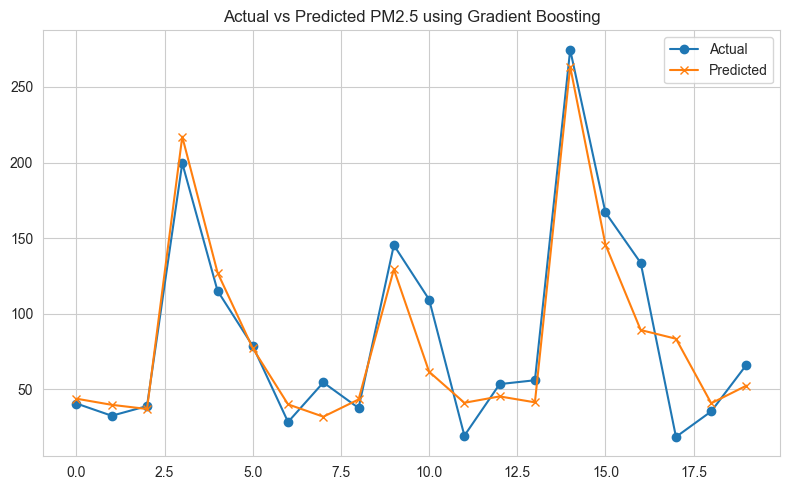

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["actual_pm25"].values, label="Actual", marker="o")
plt.plot(comparison_df["predicted_pm25"].values, label="Predicted", marker="x")
plt.title(f"Actual vs Predicted PM2.5 using {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

## Example 2: Predict on Truly New Manual Input

In [6]:
recent_pm25_history = [72.5, 75.1, 70.2, 68.0, 74.6, 79.4, 82.1, 80.0, 76.3, 74.2,
                       71.8, 69.7, 67.5, 66.1, 64.8, 63.7, 62.2, 61.9, 60.1, 59.8,
                       58.6, 57.3, 55.8, 54.1, 53.9, 52.7, 51.8, 50.6, 49.5, 48.9]

new_weather_input = {
    "Avg_Temperature": 24.5,
    "Max_Temperature": 30.8,
    "Min_Temperature": 19.6,
    "Humidity": 58.0,
    "Rainfall_Snowmelt": 0.0,
    "Visibility": 6.8,
    "Wind_Speed": 4.2,
    "Max_Sustained_Wind_Speed": 7.4,
    "City": "Bangalore",
    "Month": 11,
    "Year": 2015,
    "Day": 20,
    "DayOfWeek": 4,
    "IsWeekend": 0,
    "Season": "Post-Monsoon"
}

In [7]:
if len(recent_pm25_history) < 30:
    raise ValueError("Please provide at least 30 recent PM2.5 values for the lag features.")

history = pd.Series(recent_pm25_history)

new_input_row = dict(new_weather_input)

for lag in [1, 2, 3, 5, 7, 10, 14, 21, 30]:
    new_input_row[f"PM25_lag_{lag}"] = history.iloc[-lag]

for window in [3, 5, 7, 10, 14, 21, 30]:
    new_input_row[f"PM25_roll_mean_{window}"] = history.iloc[-window:].mean()

new_input_row["PM25_change_1"] = history.iloc[-1] - history.iloc[-2]
new_input_row["PM25_change_3"] = history.iloc[-1] - history.iloc[-4]
new_input_row["Temp_Range"] = new_input_row["Max_Temperature"] - new_input_row["Min_Temperature"]
new_input_row["Month_sin"] = np.sin(2 * np.pi * new_input_row["Month"] / 12)
new_input_row["Month_cos"] = np.cos(2 * np.pi * new_input_row["Month"] / 12)

new_input_df = pd.DataFrame([new_input_row])
new_input_df = new_input_df[feature_columns]
new_input_df

,Avg_Temperature,Max_Temperature,Min_Temperature,Humidity,Rainfall_Snowmelt,Visibility,Wind_Speed,Max_Sustained_Wind_Speed,City,Month,Year,Day,DayOfWeek,IsWeekend,Season,PM25_lag_1,PM25_lag_2,PM25_lag_3,PM25_lag_5,PM25_lag_7,PM25_lag_10,PM25_lag_14,PM25_lag_21,PM25_lag_30,PM25_roll_mean_3,PM25_roll_mean_5,PM25_roll_mean_7,PM25_roll_mean_10,PM25_roll_mean_14,PM25_roll_mean_21,PM25_roll_mean_30,PM25_change_1,PM25_change_3,Temp_Range,Month_sin,Month_cos
0,24.5,30.8,19.6,58.0,0.0,6.8,4.2,7.4,Bangalore,11,2015,20,4,0,Post-Monsoon,48.9,49.5,50.6,52.7,54.1,58.6,62.2,74.2,72.5,49.666667,50.7,51.642857,53.32,55.514286,59.761905,64.44,-0.6,-2.9,11.2,-0.5,0.866025


In [8]:
new_prediction = best_model.predict(preprocessor.transform(new_input_df))[0]
print(f"Predicted PM2.5 using {best_model_name}: {new_prediction:.2f}")

Predicted PM2.5 using Gradient Boosting: 47.94
